In [6]:
import pandas as pd
import re
from functools import reduce
from scipy.stats import pearsonr
import numpy as np
import tensorflow as tf 
from tensorflow import keras    
from tensorflow.keras import layers
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import zscore
import matplotlib.pyplot as plt  
from scipy.stats import spearmanr

In [ ]:
tf.keras.backend.clear_session()

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

### Plotting and comparing the cytokine acivity in independent cohorts

In [142]:
df_TCGA_bulk_cyt_pred=pd.read_csv("/data/kumarr17/fixed_feature_cyt_result/cyt_induced_pred_using_TCGA/"+"all_cytokines_TCGA_bulk_predictions.csv",index_col='Sample')
df_sc_pseudo_bulk_cyt_pred=pd.read_csv("/data/kumarr17/fixed_feature_cyt_result/cyt_induced_pred_using_sc_pseudobulk/"+"all_cytokines_sc_pseudo_bulk_predictions.csv",index_col='Sample')

In [143]:
df_TCGA_sc_pseudobulk_common_cyt_pred=df_TCGA_bulk_cyt_pred
df_TCGA_sc_pseudobulk_common_cyt_pred['sc_pseudo_bulk_pred_zscore']=df_sc_pseudo_bulk_cyt_pred['sc_pseudo_bulk_pred_zscore']
df_TCGA_sc_pseudobulk_common_cyt_pred_v1=df_TCGA_sc_pseudobulk_common_cyt_pred[['GSE','cytokine','TCGA_bulk_pred_zscore','sc_pseudo_bulk_pred_zscore']]

In [144]:
import os
import pandas as pd

df_annot_file = (
    df_TCGA_sc_pseudobulk_common_cyt_pred_v1[
        ['GSE', 'cytokine']
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

unq_gse = list(df_annot_file['GSE'])
unq_cyt = list(df_annot_file['cytokine'])

gse_list = []
cyt_list = []

tcga_delta_list = []
sc_delta_list = []

base_dir = "/data/kumarr17/cytosig_pre_curated_cyt_treated_data/"

for i in range(len(unq_gse)):

    current_gse = unq_gse[i]
    current_cyt = unq_cyt[i]

    annot_name = (
        current_cyt + '_' +
        current_gse +
        '_cytosig_treatment_annot.csv'
    )

    file_path = os.path.join(base_dir, annot_name)

    # ------------------------------------------------
    # Skip if annotation file does not exist
    # ------------------------------------------------
    if not os.path.exists(file_path):
        print("Skipping missing file:", annot_name)
        continue

    df_meta = pd.read_csv(
        file_path,
        index_col='ID'
    )

    # ------------------------------------------------
    # IMPORTANT:
    # Select only the current GSE + cytokine
    # ------------------------------------------------
    df_pred_tmp = (
        df_TCGA_sc_pseudobulk_common_cyt_pred_v1[
            (df_TCGA_sc_pseudobulk_common_cyt_pred_v1['GSE'] == current_gse) &
            (df_TCGA_sc_pseudobulk_common_cyt_pred_v1['cytokine'] == current_cyt)
        ]
        .copy()
    )

    # Skip if there are no prediction samples
    if df_pred_tmp.empty:
        print(
            "Skipping no prediction data:",
            current_cyt,
            current_gse
        )
        continue

    # ------------------------------------------------
    # Merge treatment annotation with prediction
    # ------------------------------------------------
    df_cyt_pre_post = pd.merge(
        df_meta,
        df_pred_tmp,
        left_index=True,
        right_index=True,
        how='inner'
    )

    # Skip empty merge
    if df_cyt_pre_post.empty:
        print(
            "Skipping empty merge:",
            current_cyt,
            current_gse
        )
        continue

    # ------------------------------------------------
    # Keep treatment + both prediction columns
    # ------------------------------------------------
    df_tmp = df_cyt_pre_post[
        [
            'Treatment',
            'TCGA_bulk_pred_zscore',
            'sc_pseudo_bulk_pred_zscore'
        ]
    ]

    # ------------------------------------------------
    # Mean prediction for each treatment group
    # ------------------------------------------------
    df_mean = (
        df_tmp
        .groupby('Treatment')
        [
            [
                'TCGA_bulk_pred_zscore',
                'sc_pseudo_bulk_pred_zscore'
            ]
        ]
        .mean()
        .reset_index()
    )

    # ------------------------------------------------
    # Skip if cytokine treatment or control missing
    # ------------------------------------------------
    if (
        current_cyt not in df_mean['Treatment'].values or
        'Control' not in df_mean['Treatment'].values
    ):
        print(
            "Skipping missing treatment/control:",
            current_cyt,
            current_gse,
            "| available:",
            df_mean['Treatment'].tolist()
        )
        continue

    # ------------------------------------------------
    # TCGA bulk prediction
    # ------------------------------------------------
    tcga_treatment = df_mean.loc[
        df_mean['Treatment'] == current_cyt,
        'TCGA_bulk_pred_zscore'
    ].iloc[0]

    tcga_control = df_mean.loc[
        df_mean['Treatment'] == 'Control',
        'TCGA_bulk_pred_zscore'
    ].iloc[0]

    tcga_delta = tcga_treatment - tcga_control

    # ------------------------------------------------
    # sc-pseudobulk prediction
    # ------------------------------------------------
    sc_treatment = df_mean.loc[
        df_mean['Treatment'] == current_cyt,
        'sc_pseudo_bulk_pred_zscore'
    ].iloc[0]

    sc_control = df_mean.loc[
        df_mean['Treatment'] == 'Control',
        'sc_pseudo_bulk_pred_zscore'
    ].iloc[0]

    sc_delta = sc_treatment - sc_control

    # ------------------------------------------------
    # Store results
    # ------------------------------------------------
    gse_list.append(current_gse)
    cyt_list.append(current_cyt)

    tcga_delta_list.append(tcga_delta)
    sc_delta_list.append(sc_delta)

    print(
        current_cyt,
        current_gse,
        "| TCGA delta =", tcga_delta,
        "| SC delta =", sc_delta
    )

TGFB1 GSE24965 | TCGA delta = 1.50639700664747 | SC delta = 1.7471536019398408
TGFB1 GSE20247 | TCGA delta = 2.072746244456711 | SC delta = -0.8936063919365086
TGFB1 GSE16416 | TCGA delta = -0.29265940290413406 | SC delta = 0.8869178851950257
TGFB1 GSE64192 | TCGA delta = -0.7814130112024932 | SC delta = 0.7773381734182835
TGFB1 GSE40374 | TCGA delta = 1.230543230124896 | SC delta = 1.8477036786421341
TGFB1 GSE51622 | TCGA delta = 1.9752869681810097 | SC delta = 1.5320173290017602
TGFB1 GSE40266 | TCGA delta = 0.32480310779642335 | SC delta = 0.6711826167045793
TGFB1 GSE23952 | TCGA delta = 1.3406821642974078 | SC delta = -1.3845581841752879
TGFB1 GSE79461 | TCGA delta = 1.5124507391336737 | SC delta = 1.1302687499532595
TGFB1 GSE123031 | TCGA delta = 2.0288115686870323 | SC delta = 1.7185371298052496
TGFB1 GSE17843 | TCGA delta = -1.7732235495189372 | SC delta = -1.29309775077301
TGFB1 GSE74580 | TCGA delta = -0.6831199617454626 | SC delta = 0.6420769772566159
TGFB1 GSE56309 | TCGA de

In [139]:
df_delta = pd.DataFrame({
    'GSE': gse_list,
    'cytokine': cyt_list,
    'TCGA_bulk_delta': tcga_delta_list,
    'sc_pseudo_bulk_delta': sc_delta_list
})

### Plotting Figure 2C¶

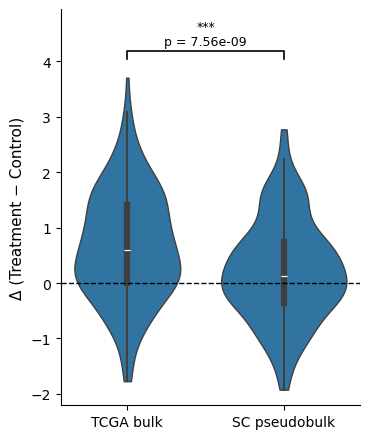

Median TCGA bulk delta: 0.6040713094387322
Median SC pseudobulk delta: 0.12169127804306384
Number of paired observations: 202
Wilcoxon statistic: 14960.0
One-sided Wilcoxon p-value: 7.556847231829303e-09


In [140]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

# ============================================================
# 1. Select paired observations
# ============================================================

plot_df = df_delta[
    [
        "TCGA_bulk_delta",
        "sc_pseudo_bulk_delta"
    ]
].dropna()


# ============================================================
# 2. Paired one-sided Wilcoxon test
# H1: TCGA_bulk_delta > sc_pseudo_bulk_delta
# ============================================================

stat, pval = wilcoxon(
    plot_df["TCGA_bulk_delta"],
    plot_df["sc_pseudo_bulk_delta"],
    alternative="greater"
)


# ============================================================
# 3. Convert to long format
# ============================================================

plot_df_long = plot_df.melt(
    var_name="Model",
    value_name="Delta"
)

plot_df_long["Model"] = plot_df_long["Model"].replace({
    "TCGA_bulk_delta": "TCGA bulk",
    "sc_pseudo_bulk_delta": "SC pseudobulk"
})


# ============================================================
# 4. Create manuscript figure
# ============================================================

fig, ax = plt.subplots(figsize=(3.8, 4.5))

sns.violinplot(
    data=plot_df_long,
    x="Model",
    y="Delta",
    inner="box",
    cut=0,
    linewidth=1,
    ax=ax
)


# ============================================================
# 5. Reference line at zero
# ============================================================

ax.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)


# ============================================================
# 6. Significance bracket
# ============================================================

y_min = plot_df_long["Delta"].min()
y_max = plot_df_long["Delta"].max()
y_range = y_max - y_min

if y_range == 0:
    y_range = 1

bracket_y = y_max + 0.06 * y_range
bracket_height = 0.025 * y_range

ax.plot(
    [0, 0, 1, 1],
    [
        bracket_y,
        bracket_y + bracket_height,
        bracket_y + bracket_height,
        bracket_y
    ],
    color="black",
    linewidth=1.2
)


# ============================================================
# 7. Significance annotation
# ============================================================

if pval < 0.001:
    significance = "***"
elif pval < 0.01:
    significance = "**"
elif pval < 0.05:
    significance = "*"
else:
    significance = "ns"

ax.text(
    0.5,
    bracket_y + bracket_height + 0.01 * y_range,
    f"{significance}\np = {pval:.2e}",
    ha="center",
    va="bottom",
    fontsize=9
)


# ============================================================
# 8. Axis formatting
# ============================================================

ax.set_ylabel(
    "Δ (Treatment − Control)",
    fontsize=11
)

ax.set_xlabel("")

ax.tick_params(
    axis="x",
    labelsize=10
)

ax.tick_params(
    axis="y",
    labelsize=10
)

ax.set_ylim(
    y_min - 0.05 * y_range,
    y_max + 0.22 * y_range
)


# ============================================================
# 9. Manuscript formatting
# ============================================================

sns.despine(ax=ax)

ax.grid(False)

plt.tight_layout()


# ============================================================
# 10. Save as vector SVG
# ============================================================

# fig.savefig(
#     "/data/kumarr17/cytokine_figure_directory/TCGA_bulk_vs_SC_pseudobulk_delta.svg",
#     format="svg",
#     bbox_inches="tight",
#     pad_inches=0.05
# )

plt.show()


# ============================================================
# 11. Print statistics
# ============================================================

print(
    "Median TCGA bulk delta:",
    plot_df["TCGA_bulk_delta"].median()
)

print(
    "Median SC pseudobulk delta:",
    plot_df["sc_pseudo_bulk_delta"].median()
)

print("Number of paired observations:", len(plot_df))
print("Wilcoxon statistic:", stat)
print("One-sided Wilcoxon p-value:", pval)

#### plotting Figure 2D

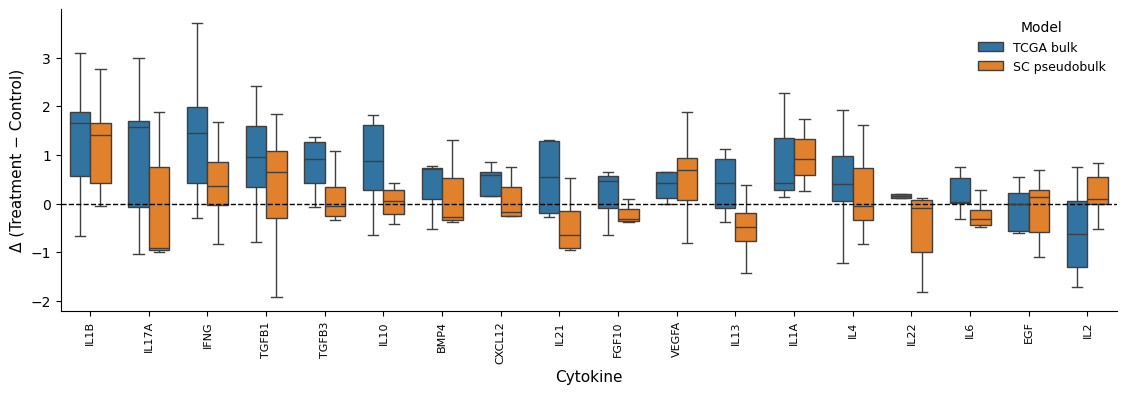

In [141]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. Prepare dataframe
# ============================================================

df_plot = df_delta.copy()

cols = [
    "TCGA_bulk_delta",
    "sc_pseudo_bulk_delta"
]


# ============================================================
# 2. Keep cytokines with at least 3 unique cohorts
# ============================================================

valid_cytokines = (
    df_plot
    .groupby("cytokine")["GSE"]
    .nunique()
)

valid_cytokines = valid_cytokines[
    valid_cytokines >= 3
].index

df_plot = df_plot[
    df_plot["cytokine"].isin(valid_cytokines)
].copy()


# ============================================================
# 3. Order cytokines by median TCGA-bulk delta
#    descending: highest -> lowest
# ============================================================

cytokine_order = (
    df_plot
    .groupby("cytokine")["TCGA_bulk_delta"]
    .median()
    .sort_values(ascending=False)
    .index
)


# ============================================================
# 4. Convert to long format
# ============================================================

df_long = df_plot.melt(
    id_vars=["GSE", "cytokine"],
    value_vars=cols,
    var_name="Model",
    value_name="Delta"
)

df_long["Model"] = df_long["Model"].replace({
    "TCGA_bulk_delta": "TCGA bulk",
    "sc_pseudo_bulk_delta": "SC pseudobulk"
})


# ============================================================
# 5. Create manuscript figure
# ============================================================

fig, ax = plt.subplots(figsize=(12, 4.5))

sns.boxplot(
    data=df_long,
    x="cytokine",
    y="Delta",
    hue="Model",
    order=cytokine_order,
    showfliers=False,
    width=0.7,
    linewidth=1,
    ax=ax
)


# ============================================================
# 6. Zero reference line
# ============================================================

ax.axhline(
    y=0,
    linestyle="--",
    color="black",
    linewidth=1
)


# ============================================================
# 7. Axis formatting
# ============================================================

ax.set_xlabel(
    "Cytokine",
    fontsize=11
)

ax.set_ylabel(
    "Δ (Treatment − Control)",
    fontsize=11
)

ax.tick_params(
    axis="x",
    labelrotation=90,
    labelsize=8
)

ax.tick_params(
    axis="y",
    labelsize=10
)


# ============================================================
# 8. Legend
# ============================================================

ax.legend(
    title="Model",
    frameon=False,
    fontsize=9,
    title_fontsize=10
)


# ============================================================
# 9. Manuscript formatting
# ============================================================

sns.despine(ax=ax)

ax.grid(False)

fig.subplots_adjust(
    left=0.10,
    right=0.98,
    bottom=0.30,
    top=0.97
)


# ============================================================
# 10. Save as vector SVG
# ============================================================

# fig.savefig(
#     "/data/kumarr17/cytokine_figure_directory/"
#     "TCGA_bulk_vs_SC_pseudobulk_delta_by_cytokine.svg",
#     format="svg",
#     bbox_inches="tight",
#     pad_inches=0.05
# )

plt.show()